In [1]:
import os
import datetime
import warnings
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from sklearn.metrics import mean_absolute_error
from models import create_arcface_model

warnings.filterwarnings('ignore')
print('TensorFlow version:', tf.__version__)



TensorFlow version: 2.15.0


In [2]:
train_ds = tf.data.Dataset.load(r'data\videoface_100\train_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.load(r'data\videoface_100\val_ds') \
    .cache().shuffle(buffer_size=1000, seed=42).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, valid_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 10, 112, 112, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>)

Load Arcface


In [3]:
# ── [Cell 3] Verifikasi: Load ArcFace pre-trained weights ──────────────────
# Cell ini hanya untuk memastikan create_arcface_model() berjalan dengan benar.
# arcface_112 yang dibuat di sini akan DIGUNAKAN LANGSUNG di Cell 4.
arcface_112 = create_arcface_model(load_weights=True)
arcface_112.trainable = False

print(f'\nArcFace output shape: {arcface_112.output_shape}')  # Harusnya (None, 512)
print(f'Jumlah layer ArcFace : {len(arcface_112.layers)}')
print(f'Trainable            : {arcface_112.trainable}')




✓ ArcFace weights berhasil dimuat dari: c:\Users\ALFIAN\TA_CODING\ZIP_FILE\arcface_oceanmodel\ocean-project-deepface\arcface_weights.h5

ArcFace output shape: (None, 512)
Jumlah layer ArcFace : 163
Trainable            : False


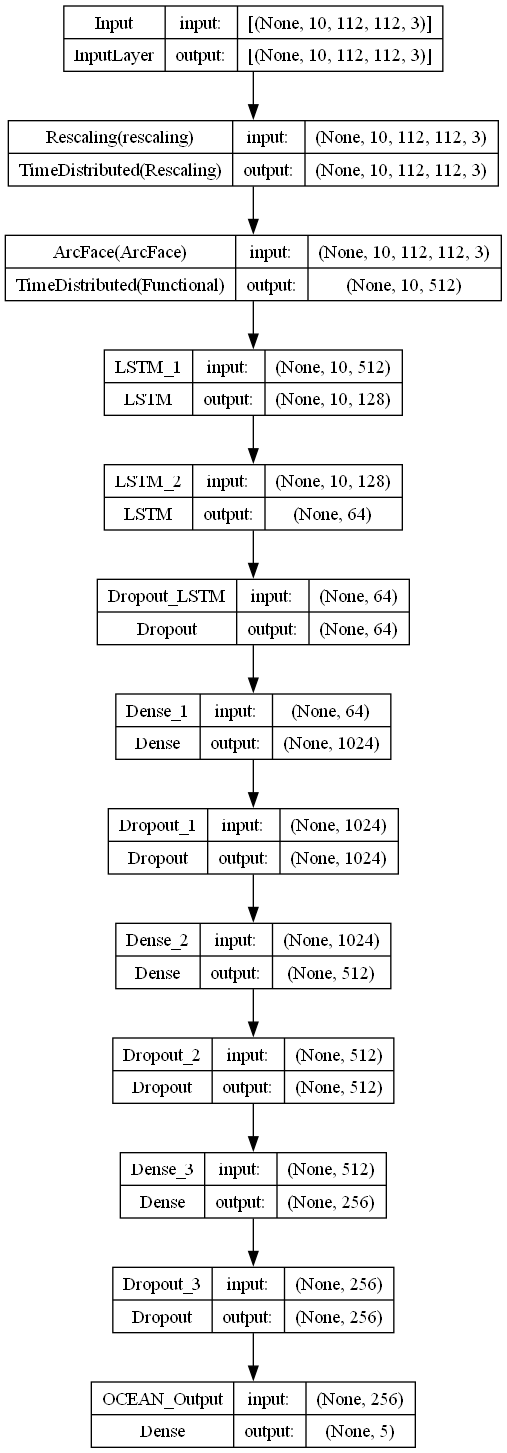

In [4]:
# ── [Cell 4] Bangun model prediksi kepribadian OCEAN ───────────────────────
# CATATAN: arcface_112 sudah di-load di Cell 3, tidak perlu di-load ulang.

inputs = keras.layers.Input(shape=(10, 112, 112, 3), name='Input')

# Rescale [0,255] → [0,1]
x = keras.layers.TimeDistributed(
    keras.layers.Rescaling(scale=1./255.0), name='Rescaling'
)(inputs)

# Ekstrak ArcFace embedding per-frame → (batch, 10, 512)
x = keras.layers.TimeDistributed(arcface_112, name='ArcFace')(x)

# Temporal modelling dengan LSTM
x = keras.layers.LSTM(units=128, return_sequences=True, name='LSTM_1')(x)
x = keras.layers.LSTM(units=64, name='LSTM_2')(x)
x = keras.layers.Dropout(0.2, name='Dropout_LSTM')(x)

# Dense head
x = keras.layers.Dense(1024, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01), name='Dense_1')(x)
x = keras.layers.Dropout(0.3, name='Dropout_1')(x)

x = keras.layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01), name='Dense_2')(x)
x = keras.layers.Dropout(0.3, name='Dropout_2')(x)

x = keras.layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(0.01), name='Dense_3')(x)
x = keras.layers.Dropout(0.5, name='Dropout_3')(x)

# Output: 5 trait OCEAN, nilai antara 0–1
output = keras.layers.Dense(5, activation='sigmoid', name='OCEAN_Output')(x)

model = keras.models.Model(inputs=inputs, outputs=output,
                            name='Arcface_OCEAN')
keras.utils.plot_model(model, show_shapes=True)


In [5]:
# ── [Cell 5] Setup training — No Optimizer (SGD default keras) ─────────────
t = datetime.datetime.now().strftime('%m%d_%H%M%S')

# Tanpa optimizer eksplisit → Keras pakai SGD default (baseline mentah)
# Weights tersimpan dalam format .h5 agar bisa langsung di-load Flask
os.makedirs(f'./weights/faces/{t}', exist_ok=True)
weight_path = f'./weights/faces/{t}/face.h5'

early_stopping = keras.callbacks.EarlyStopping(
    patience=10, verbose=1, restore_best_weights=True
)
check_point = keras.callbacks.ModelCheckpoint(
    filepath=weight_path,
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    save_format='h5',       # Pastikan format h5 agar kompatibel dengan Flask
    verbose=1
)

# Compile tanpa optimizer → Keras akan pakai SGD default sebagai baseline
model.compile(loss='mse', metrics=['mae'])
print(f'Weights akan disimpan ke: {weight_path}')



Weights akan disimpan ke: ./weights/faces/0410_011142/face.h5


In [6]:
history = model.fit(train_ds, validation_data=valid_ds, batch_size=8, epochs=100, callbacks=[early_stopping, check_point])

Epoch 1/100


8/8 [==============================] - ETA: 0s - loss: 9.0954 - mae: 0.1377
Epoch 1: val_mae improved from inf to 0.12967, saving model to ./weights/faces/0410_011142\face.h5
8/8 [==============================] - 28s 3s/step - loss: 9.0954 - mae: 0.1377 - val_loss: 6.8201 - val_mae: 0.1297
Epoch 2/100
8/8 [==============================] - ETA: 0s - loss: 5.7703 - mae: 0.1346
Epoch 2: val_mae improved from 0.12967 to 0.12794, saving model to ./weights/faces/0410_011142\face.h5
8/8 [==============================] - 21s 3s/step - loss: 5.7703 - mae: 0.1346 - val_loss: 4.5311 - val_mae: 0.1279
Epoch 3/100
8/8 [==============================] - ETA: 0s - loss: 3.7963 - mae: 0.1341
Epoch 3: val_mae improved from 0.12794 to 0.12675, saving model to ./weights/faces/0410_011142\face.h5
8/8 [==============================] - 20s 3s/step - loss: 3.7963 - mae: 0.1341 - val_loss: 3.0137 - val_mae: 0.1267
Epoch 4/100
8/8 [==============================] - ETA: 0s - loss: 2.5592 - ma

### Load weights

In [7]:
# ── [Cell 8] Load weights (OPSIONAL) ──────────────────────────────────────
# PERHATIAN: Jalankan cell ini HANYA jika:
#   - Kamu mau load ulang weights tanpa training dari awal
#   - Atau kernel restart setelah training selesai
#
# Jika baru selesai training (Cell 6 baru dijalankan),
# LEWATI cell ini -- model di memori sudah punya weights terbaik.
#
# Jika perlu load ulang, uncomment baris di bawah dan sesuaikan path:
# model.load_weights(f'weights/faces/{t}/face.h5')
# print(f'Weights di-load dari: weights/faces/{t}/face.h5')
print('Cell 8 di-skip. Model menggunakan weights hasil training terbaru.')


Cell 8 di-skip. Model menggunakan weights hasil training terbaru.


In [8]:
# ── [Cell 8b] Simpan full model untuk deployment Flask ─────────────────────
# Simpan arsitektur + weights dalam satu file .h5
# File ini yang di-load langsung oleh Flask dengan keras.models.load_model()
full_model_path = f'weights/{t}/face_full_model.h5'
model.save(full_model_path)
print(f'Full model disimpan ke: {full_model_path}')
print('Gunakan file ini di Flask dengan: keras.models.load_model(path)')


Full model disimpan ke: weights/0410_011142/face_full_model.h5
Gunakan file ini di Flask dengan: keras.models.load_model(path)


## Evaluation

### Training data

In [9]:
train_ds = tf.data.Dataset.load(r'data\videoface_100\train_ds') 
loss, mae = model.evaluate(train_ds)
(1-mae)*100

8/8 [==============================] - 15s 2s/step - loss: 0.0270 - mae: 0.1278


87.21753805875778

In [10]:
y_true = np.concatenate([y for x,y in train_ds])
y_pred = model.predict(train_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

8/8 [==============================] - 16s 2s/step


(array([88.51852, 85.24272, 87.4875 , 88.58791, 86.25103], dtype=float32),
 87.21753656864166)

### Validation data

In [11]:
valid_ds = tf.data.Dataset.load(r'data\videoface_100\val_ds') 
loss, mae = model.evaluate(valid_ds)
(1-mae)*100

3/3 [==============================] - 5s 1s/step - loss: 0.0179 - mae: 0.1174


88.25707882642746

In [12]:
y_true = np.concatenate([y for x,y in valid_ds])
y_pred = model.predict(valid_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 1s/step


(array([88.74599 , 87.370636, 88.79074 , 90.480225, 85.897804],
       dtype=float32),
 88.25708031654358)

### Test data

In [13]:
test_ds = tf.data.Dataset.load(r'data\videoface_100\test_ds')
loss, mae = model.evaluate(test_ds)
(1-mae)*100

3/3 [==============================] - 5s 1s/step - loss: 0.0310 - mae: 0.1397


86.03107631206512

In [14]:
y_true = np.concatenate([y for x,y in test_ds])
y_pred = model.predict(test_ds)

mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
(1-mae)*100, (1-np.mean(mae))*100

3/3 [==============================] - 5s 2s/step


(array([88.44444 , 84.02913 , 87.309555, 87.08791 , 83.28434 ],
       dtype=float32),
 86.031074821949)

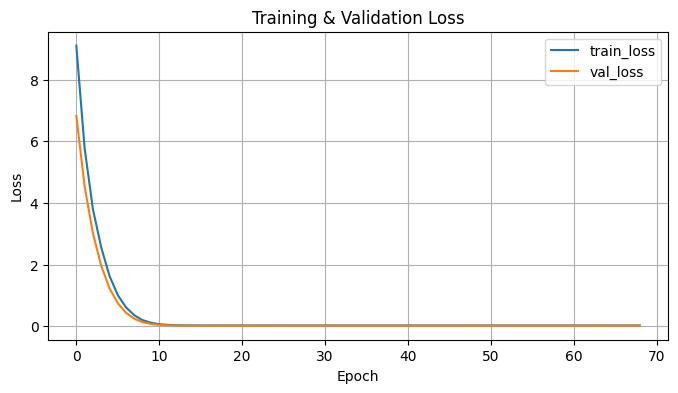

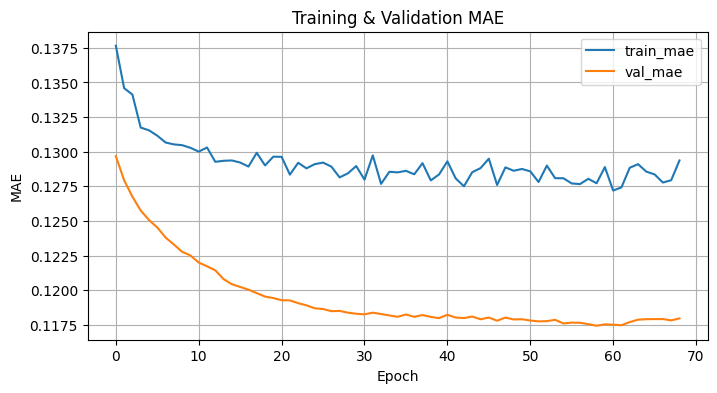

In [15]:
import matplotlib.pyplot as plt

# 1) Plot Loss
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'],    label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 2) Plot MAE (atau metric lain yang kamu pakai)
plt.figure(figsize=(8,4))
plt.plot(history.history['mae'],     label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')
plt.title('Training & Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

---
## Evaluasi Tambahan


In [16]:
# ── [Eval 1] Tabel Ringkasan Per Trait OCEAN ─────────────────────────────
import pandas as pd

TRAITS = ['Openness', 'Conscientiousness', 'Extraversion', 'Agreeableness', 'Neuroticism']

# Hitung MAE per trait untuk setiap split
def compute_summary(ds, label):
    y_true = []
    y_pred_list = []
    for x_batch, y_batch in ds:
        y_true.append(y_batch.numpy())
        y_pred_list.append(model.predict(x_batch, verbose=0))
    y_true = __import__('numpy').vstack(y_true)
    y_pred = __import__('numpy').vstack(y_pred_list)
    mae_per_trait = __import__('numpy').abs(y_true - y_pred).mean(axis=0)
    acc_per_trait = (1 - mae_per_trait) * 100
    return mae_per_trait, acc_per_trait

train_ds_eval = tf.data.Dataset.load(r'data\videoface_100\train_ds')
valid_ds_eval = tf.data.Dataset.load(r'data\videoface_100\val_ds')
test_ds_eval  = tf.data.Dataset.load(r'data\videoface_100\test_ds')

mae_train, acc_train = compute_summary(train_ds_eval, 'Train')
mae_val,   acc_val   = compute_summary(valid_ds_eval, 'Val')
mae_test,  acc_test  = compute_summary(test_ds_eval,  'Test')

rows = []
for i, t in enumerate(TRAITS):
    rows.append({
        'Trait'          : t,
        'MAE Train'      : f'{mae_train[i]:.4f}',
        'Acc Train (%)'  : f'{acc_train[i]:.2f}',
        'MAE Val'        : f'{mae_val[i]:.4f}',
        'Acc Val (%)'    : f'{acc_val[i]:.2f}',
        'MAE Test'       : f'{mae_test[i]:.4f}',
        'Acc Test (%)'   : f'{acc_test[i]:.2f}',
    })

# Row rata-rata
rows.append({
    'Trait'         : 'RATA-RATA',
    'MAE Train'     : f'{mae_train.mean():.4f}',
    'Acc Train (%)' : f'{acc_train.mean():.2f}',
    'MAE Val'       : f'{mae_val.mean():.4f}',
    'Acc Val (%)'   : f'{acc_val.mean():.2f}',
    'MAE Test'      : f'{mae_test.mean():.4f}',
    'Acc Test (%)'  : f'{acc_test.mean():.2f}',
})

df_summary = pd.DataFrame(rows).set_index('Trait')
print('\n=== Tabel Ringkasan Evaluasi Per Trait OCEAN ===')
print(df_summary.to_string())
df_summary



=== Tabel Ringkasan Evaluasi Per Trait OCEAN ===
                  MAE Train Acc Train (%) MAE Val Acc Val (%) MAE Test Acc Test (%)
Trait                                                                              
Openness             0.1148         88.52  0.1125       88.75   0.1156        88.44
Conscientiousness    0.1476         85.24  0.1263       87.37   0.1597        84.03
Extraversion         0.1251         87.49  0.1121       88.79   0.1269        87.31
Agreeableness        0.1141         88.59  0.0952       90.48   0.1291        87.09
Neuroticism          0.1375         86.25  0.1410       85.90   0.1672        83.28
RATA-RATA            0.1278         87.22  0.1174       88.26   0.1397        86.03


,MAE Train,Acc Train (%),MAE Val,Acc Val (%),MAE Test,Acc Test (%)
Trait,,,,,,
Openness,0.1148,88.52,0.1125,88.75,0.1156,88.44
Conscientiousness,0.1476,85.24,0.1263,87.37,0.1597,84.03
Extraversion,0.1251,87.49,0.1121,88.79,0.1269,87.31
Agreeableness,0.1141,88.59,0.0952,90.48,0.1291,87.09
Neuroticism,0.1375,86.25,0.1410,85.90,0.1672,83.28
RATA-RATA,0.1278,87.22,0.1174,88.26,0.1397,86.03


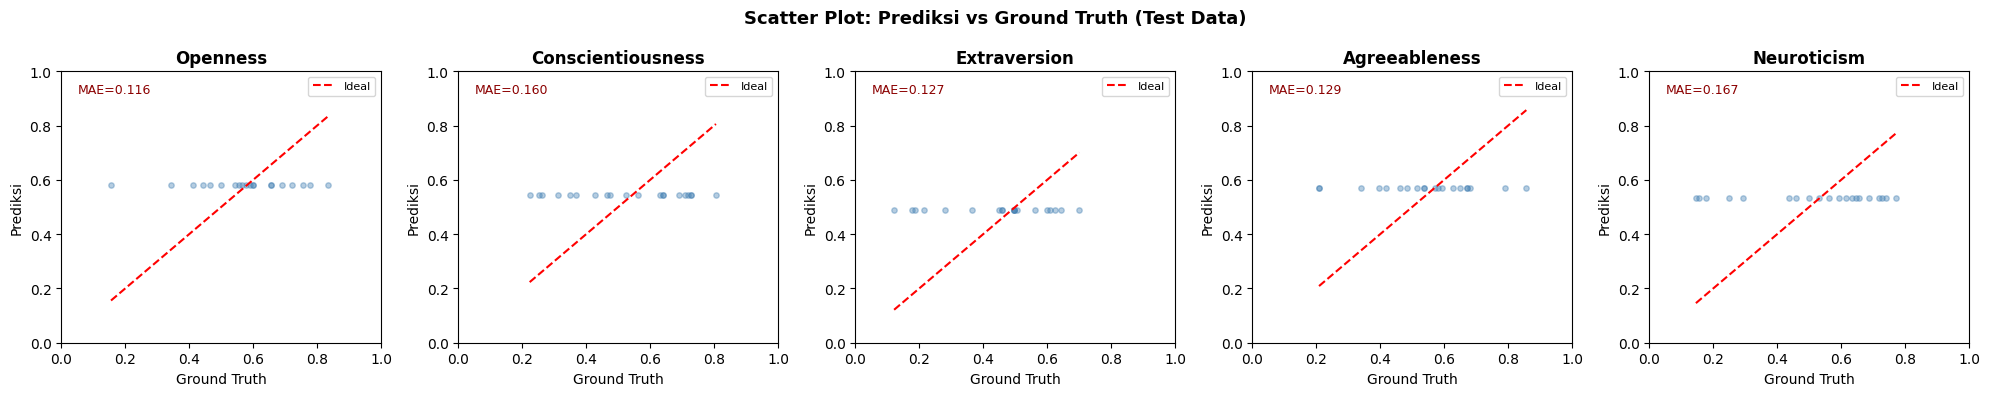

Grafik disimpan: scatter_pred_vs_gt.png


In [17]:
# ── [Eval 2] Scatter Plot: Prediksi vs Ground Truth (Test Data) ───────────
import matplotlib.pyplot as plt
import numpy as np

# Ambil y_true dan y_pred dari test set
test_ds_sc = tf.data.Dataset.load(r'data\videoface_100\test_ds')
y_true_all = np.concatenate([y.numpy() for _, y in test_ds_sc])
y_pred_all = model.predict(test_ds_sc, verbose=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Scatter Plot: Prediksi vs Ground Truth (Test Data)', fontsize=13, fontweight='bold')

for i, (ax, trait) in enumerate(zip(axes, TRAITS)):
    yt = y_true_all[:, i]
    yp = y_pred_all[:, i]
    ax.scatter(yt, yp, alpha=0.4, s=15, color='steelblue')
    # Garis diagonal ideal
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
    ax.set_title(trait, fontweight='bold')
    ax.set_xlabel('Ground Truth')
    ax.set_ylabel('Prediksi')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    mae_i = np.abs(yt - yp).mean()
    ax.text(0.05, 0.92, f'MAE={mae_i:.3f}', transform=ax.transAxes,
            fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig('scatter_pred_vs_gt.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafik disimpan: scatter_pred_vs_gt.png')


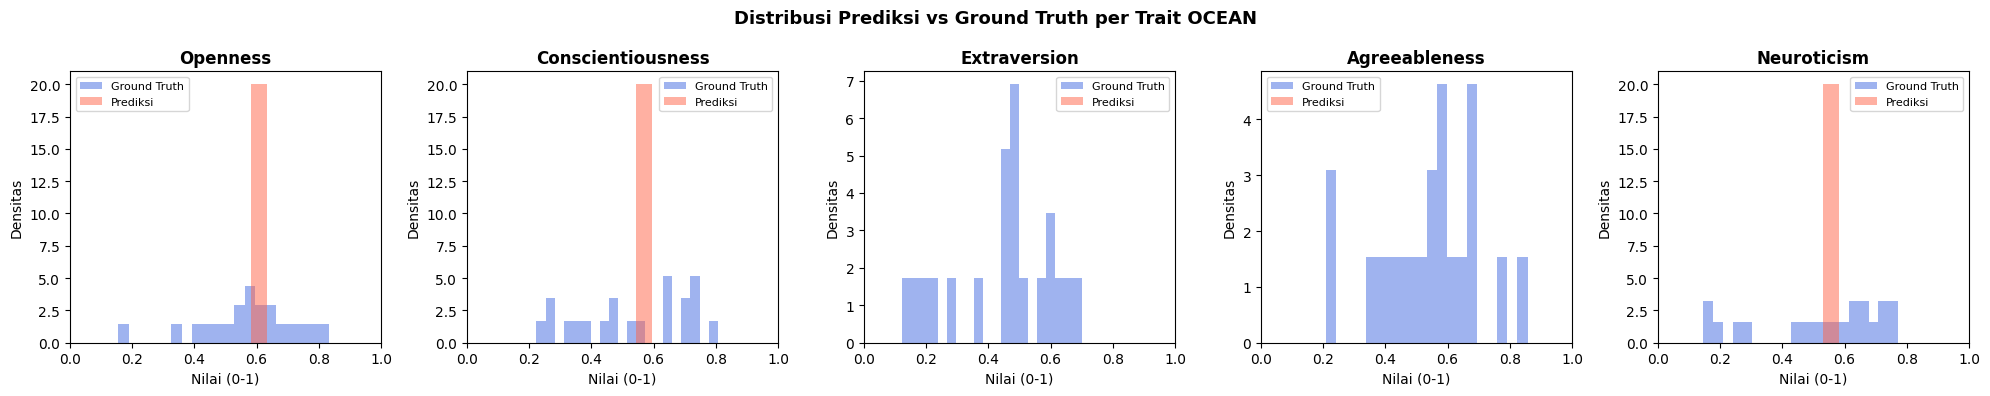

Grafik disimpan: histogram_distribusi.png

CATATAN: Jika histogram Prediksi (merah) menumpuk di satu titik
         dan tidak mengikuti Ground Truth (biru) --> model STUCK.


In [18]:
# ── [Eval 3] Histogram: Distribusi Prediksi vs Ground Truth (Test Data) ───
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Distribusi Prediksi vs Ground Truth per Trait OCEAN', fontsize=13, fontweight='bold')

for i, (ax, trait) in enumerate(zip(axes, TRAITS)):
    ax.hist(y_true_all[:, i], bins=20, alpha=0.5, color='royalblue',
            label='Ground Truth', density=True)
    ax.hist(y_pred_all[:, i], bins=20, alpha=0.5, color='tomato',
            label='Prediksi', density=True)
    ax.set_title(trait, fontweight='bold')
    ax.set_xlabel('Nilai (0-1)')
    ax.set_ylabel('Densitas')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('histogram_distribusi.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafik disimpan: histogram_distribusi.png')
print()
print('CATATAN: Jika histogram Prediksi (merah) menumpuk di satu titik')
print('         dan tidak mengikuti Ground Truth (biru) --> model STUCK.')


In [19]:
# ── [Eval 4] Tabel Training Summary ───────────────────────────────────────
import numpy as np

val_maes   = history.history['val_mae']
best_epoch = int(np.argmin(val_maes)) + 1
best_val   = min(val_maes)
last_epoch = len(val_maes)

print('=' * 45)
print('         TRAINING SUMMARY')
print('=' * 45)
print(f'  Notebook        : 02_Face_nooptimizer')
print(f'  Optimizer       : None (Keras default SGD)')
print(f'  Total Epoch     : {last_epoch}')
print(f'  Best Epoch      : {best_epoch}')
print(f'  Best Val MAE    : {best_val:.4f}')
print(f'  Best Val Acc    : {(1-best_val)*100:.2f}%')
print(f'  Test MAE (rata) : {mae_test.mean():.4f}')
print(f'  Test Acc (rata) : {acc_test.mean():.2f}%')
print('=' * 45)
print()
print('Per Trait Test Accuracy:')
for trait, acc in zip(TRAITS, acc_test):
    bar = '#' * int(acc / 5)
    print(f'  {trait:18s}: {acc:5.2f}% |{bar}')


         TRAINING SUMMARY
  Notebook        : 02_Face_nooptimizer
  Optimizer       : None (Keras default SGD)
  Total Epoch     : 69
  Best Epoch      : 59
  Best Val MAE    : 0.1174
  Best Val Acc    : 88.26%
  Test MAE (rata) : 0.1397
  Test Acc (rata) : 86.03%

Per Trait Test Accuracy:
  Openness          : 88.44% |#################
  Conscientiousness : 84.03% |################
  Extraversion      : 87.31% |#################
  Agreeableness     : 87.09% |#################
  Neuroticism       : 83.28% |################
